 [1] TIMELINE AND TDMA STATE
robot |   t_first |    t_last |  dur[s] |    n |  frame_min  frame_max |  sync_lost |  slot_min  slot_max
------------------------------------------------------------------------------------------------------------
    2 |     85615 |    115391 |   29.78 |  124 |        349        472 |      0.000 |         0        15
    3 |     83623 |    113401 |   29.78 |  124 |        349        472 |      0.000 |         0        15
    4 |     81470 |    111247 |   29.78 |  124 |        349        472 |      0.000 |         0        15

 [2] SLOT VISITING PATTERN

robot | s 0 s 1 s 2 s 3 s 4 s 5 s 6 s 7 s 8 s 9 s10 s11 s12 s13 s14 s15
------------------------------------------------------------------------------------
    2 |   8   8   8   8   8   8   8   8   8   7   7   7   7   8   8   8
    3 |   8   8   8   8   8   8   8   8   8   7   7   7   7   8   8   8
    4 |   8   8   8   8   8   8   8   8   8   7   7   7   7   8   8   8

 [3] UWB DATA PRESENCE  (nonzero ra

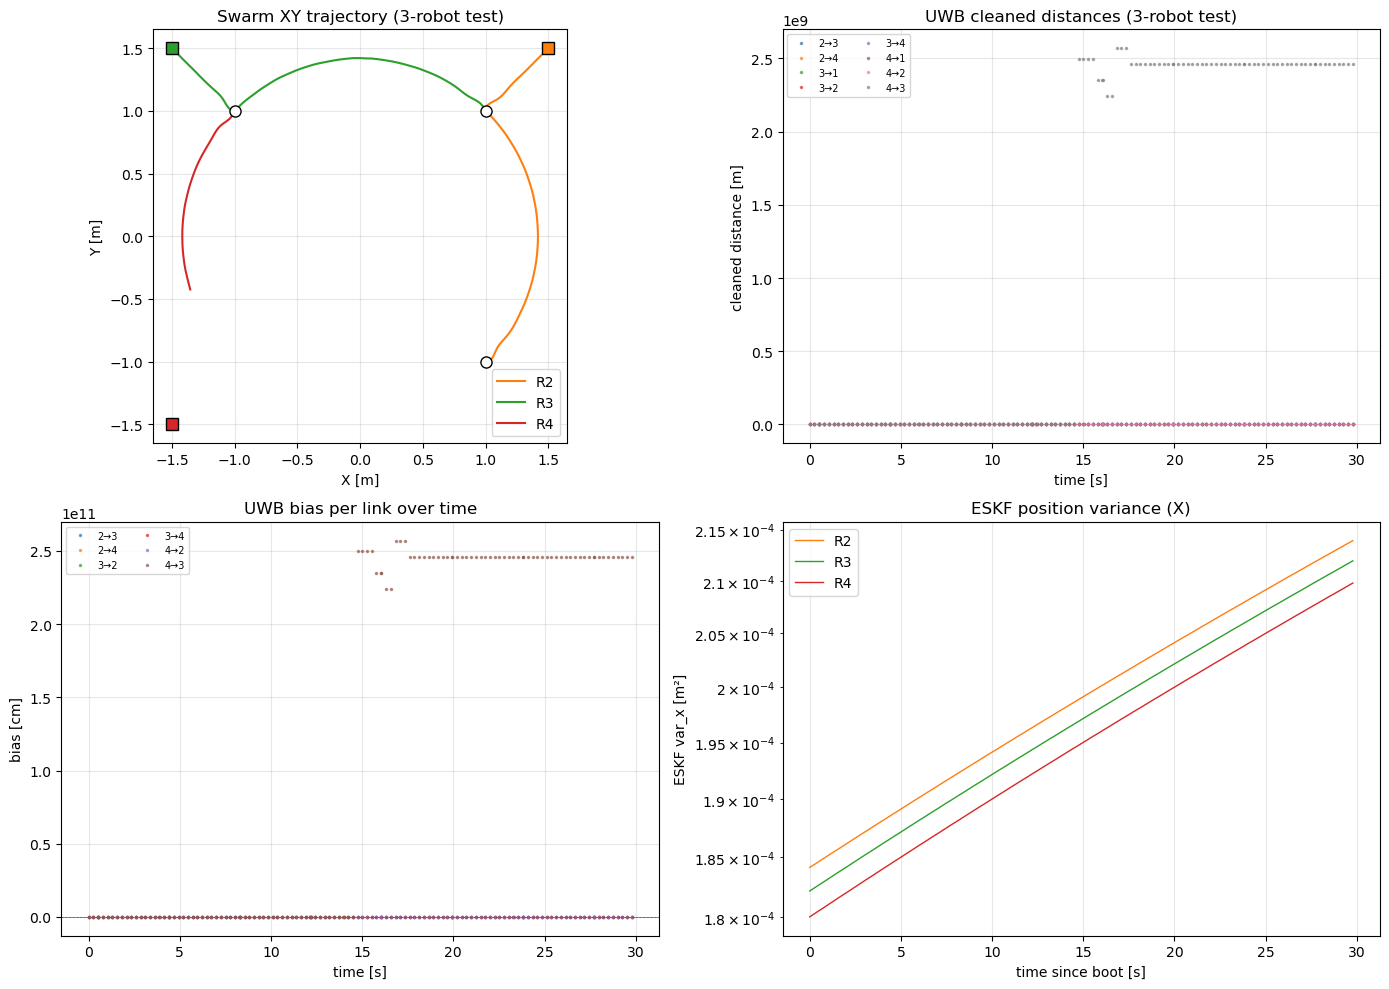

In [1]:
# ============================================================
# 3-robot test analysis — antenna orientation + R1 absence
# ============================================================
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 300)

# ------------------------------------------------------------
# 0. Load three-robot logs
# ------------------------------------------------------------
FILES = {
    2: "robot_2_v2.csv",
    3: "robot_3_v2.csv",
    4: "robot_4_v2.csv",
}

data = {}
for rb, fname in FILES.items():
    p = Path(fname)
    if p.exists():
        data[rb] = pd.read_csv(p)

ACTIVE = (2, 3, 4)
WHEEL_RADIUS_M = 0.026850
TRACK_WIDTH = {2: 0.1248, 3: 0.1163, 4: 0.1209}

L_INITIAL     = 2.0
L_FINAL       = 3.0
ROT_FINAL_RAD = np.pi / 2
T1_ROT_SEC    = 20.0
T2_SCALE_SEC  = 10.0
T_TOTAL_SEC   = T1_ROT_SEC + T2_SCALE_SEC

UNIT_OFFSET = {
    2: (+0.5, -0.5),
    3: (+0.5, +0.5),
    4: (-0.5, +0.5),
}

def quintic(s):
    return 10*s**3 - 15*s**4 + 6*s**5

def ref_pose(rb, t_elapsed):
    if t_elapsed < T1_ROT_SEC:
        tau = t_elapsed / T1_ROT_SEC
        s = quintic(max(0.0, min(1.0, tau)))
        phi = ROT_FINAL_RAD * s
        L = L_INITIAL
    elif t_elapsed < T_TOTAL_SEC:
        tau = (t_elapsed - T1_ROT_SEC) / T2_SCALE_SEC
        s = quintic(max(0.0, min(1.0, tau)))
        phi = ROT_FINAL_RAD
        L = L_INITIAL + (L_FINAL - L_INITIAL) * s
    else:
        phi = ROT_FINAL_RAD
        L = L_FINAL
    rx, ry = UNIT_OFFSET[rb]
    c, s_ = np.cos(phi), np.sin(phi)
    return c * L * rx - s_ * L * ry, s_ * L * rx + c * L * ry, phi

# ============================================================
# [1] TIMELINE AND TDMA STATE
# ============================================================
print("=" * 100)
print(" [1] TIMELINE AND TDMA STATE")
print("=" * 100)
print(f"{'robot':>5s} | {'t_first':>9s} | {'t_last':>9s} | {'dur[s]':>7s} | "
      f"{'n':>4s} | {'frame_min':>10s} {'frame_max':>10s} | "
      f"{'sync_lost':>10s} | {'slot_min':>9s} {'slot_max':>9s}")
print("-" * 108)

maneuver_start = {}
for rb, d in data.items():
    t0 = int(d["t_ms"].iloc[0])
    t1 = int(d["t_ms"].iloc[-1])
    dur = (t1 - t0) / 1000.0
    frmin = int(d["tdma_frame_id"].min())
    frmax = int(d["tdma_frame_id"].max())
    slf = d["tdma_sync_lost"].mean()
    slmin = int(d["tdma_slot_index"].min())
    slmax = int(d["tdma_slot_index"].max())
    if "robot_state" in d.columns:
        first_run = np.where(d["robot_state"].values == 1)[0]
        maneuver_start[rb] = int(d["t_ms"].iloc[first_run[0]]) if len(first_run) else -1
    else:
        maneuver_start[rb] = -1
    print(f"{rb:>5d} | {t0:>9d} | {t1:>9d} | {dur:>7.2f} | "
          f"{len(d):>4d} | {frmin:>10d} {frmax:>10d} | "
          f"{slf:>10.3f} | {slmin:>9d} {slmax:>9d}")

# ============================================================
# [2] SLOT VISITING PATTERN
# ============================================================
print("\n" + "=" * 100)
print(" [2] SLOT VISITING PATTERN")
print("=" * 100)
print(f"\n{'robot':>5s} | " + " ".join(f"s{s:>2d}" for s in range(16)))
print("-" * 84)
for rb, d in data.items():
    if "tdma_slot_index" not in d.columns: continue
    counts = d["tdma_slot_index"].value_counts().to_dict()
    row = f"{rb:>5d} | "
    cells = [f"{counts.get(s, 0):>3d}" for s in range(16)]
    print(row + " ".join(cells))

# ============================================================
# [3] UWB DATA PRESENCE
# ============================================================
print("\n" + "=" * 100)
print(" [3] UWB DATA PRESENCE  (nonzero raw per block, peer_id breakdown)")
print("=" * 100)

for rb, d in data.items():
    print(f"\n  R{rb}:")
    for i in (1, 2, 3):
        peer_col = f"uwb{i}_peer_id"
        raw_col  = f"uwb{i}_raw"
        if raw_col not in d.columns: continue
        nz = int((d[raw_col].abs() > 1e-6).sum())
        total = len(d)
        peers = d[peer_col].value_counts().to_dict()
        print(f"    uwb{i}: nonzero={nz:>4d}/{total:>4d}  peer_ids={peers}")

# ============================================================
# [4] LINK-LEVEL UWB SUMMARY
# ============================================================
print("\n" + "=" * 100)
print(" [4] LINK-LEVEL UWB SUMMARY")
print("=" * 100)

# Build link_data
link_data = {}
for rb, d in data.items():
    for i in (1, 2, 3):
        peer_col = f"uwb{i}_peer_id"
        raw_col  = f"uwb{i}_raw"
        cln_col  = f"uwb{i}_clean"
        rssi_col = f"uwb{i}_rssi"
        fp_col   = f"uwb{i}_fp_power"
        noise_col = f"uwb{i}_std_noise"
        if peer_col not in d.columns: continue

        for _, row in d.iterrows():
            peer = int(row[peer_col])
            raw  = row[raw_col]
            if abs(raw) < 1e-6: continue
            key = (rb, peer)
            link_data.setdefault(key, []).append({
                "t_ms":  int(row["t_ms"]),
                "raw":   raw,
                "clean": row[cln_col],
                "rssi":  row[rssi_col],
                "fp_power": row[fp_col],
                "noise": row[noise_col],
            })

print(f"{'link':>6s} | {'n':>4s} | "
      f"{'raw_mean':>10s} | {'clean_mean':>11s} | "
      f"{'rssi_mean':>10s} | {'noise_mean':>10s}")
print("-" * 70)
for key in sorted(link_data.keys()):
    vals = link_data[key]
    if len(vals) < 3: continue
    raw_m   = np.mean([v["raw"]      for v in vals])
    clean_m = np.mean([v["clean"]    for v in vals])
    rssi_m  = np.mean([v["rssi"]     for v in vals])
    noise_m = np.mean([v["noise"]    for v in vals])
    print(f"{key[0]}->{key[1]} | {len(vals):>4d} | "
          f"{raw_m:>+10.3f} | {clean_m:>+11.3f} | "
          f"{rssi_m:>+10.2f} | {noise_m:>10.1f}")

# ============================================================
# [5] BIAS vs GROUND-TRUTH REFERENCE
# ============================================================
print("\n" + "=" * 100)
print(" [5] BIAS vs GROUND-TRUTH REFERENCE")
print("=" * 100)
print(f"{'link':>6s} | {'n':>4s} | "
      f"{'gt_mean':>9s} | {'clean_mean':>11s} | "
      f"{'bias [cm]':>10s} | {'rmse [cm]':>10s} | "
      f"{'clean_std':>10s}")
print("-" * 76)

results = {}
for key in sorted(link_data.keys()):
    rb_i, rb_j = key
    if rb_i not in maneuver_start or rb_j not in maneuver_start: continue
    t0_i = maneuver_start[rb_i]
    t0_j = maneuver_start[rb_j]
    if t0_i < 0 or t0_j < 0: continue

    vals = link_data[key]
    if len(vals) < 3: continue

    gt_arr = []
    cln_arr = []
    for v in vals:
        xa, ya, _ = ref_pose(rb_i, (v["t_ms"] - t0_i) / 1000.0)
        xb, yb, _ = ref_pose(rb_j, (v["t_ms"] - t0_j) / 1000.0)
        gt_arr.append(np.hypot(xa - xb, ya - yb))
        cln_arr.append(v["clean"])

    gt_arr  = np.array(gt_arr)
    cln_arr = np.array(cln_arr)
    bias = cln_arr - gt_arr
    rmse = np.sqrt(np.mean(bias ** 2))

    results[key] = {
        "bias_mean": float(bias.mean()),
        "rmse": float(rmse),
        "clean_std": float(np.std(cln_arr)),
        "n": len(vals),
    }

    print(f"{rb_i}->{rb_j} | {len(vals):>4d} | "
          f"{gt_arr.mean():>9.3f} | {cln_arr.mean():>11.3f} | "
          f"{bias.mean()*100:>+10.2f} | {rmse*100:>10.2f} | "
          f"{np.std(cln_arr)*100:>10.2f}")

# ============================================================
# [6] COMPARISON WITH PREVIOUS 4-ROBOT TEST
# ============================================================
print("\n" + "=" * 100)
print(" [6] COMPARISON WITH PREVIOUS 4-ROBOT TEST")
print("=" * 100)
print("  Previous biases were computed on the same quintic reference.")
print("  Negative bias means the UWB reports shorter than truth.")

prev_bias = {
    (2, 3): +9.62,
    (3, 2): -69.24,
    (2, 4): -17.80,
    (4, 2): -55.50,
    (3, 4): -22.38,
    (4, 3): +22.36,
    (2, 1): +160.19,
    (4, 1): +6854.88,
    (1, 4): +8889.19,
}

print(f"\n{'link':>6s} | {'prev bias [cm]':>15s} | "
      f"{'now bias [cm]':>14s} | {'Δ [cm]':>10s}")
print("-" * 62)
for key in sorted(results.keys()):
    if key not in prev_bias: continue
    prev = prev_bias[key]
    now  = results[key]["bias_mean"] * 100
    delta = now - prev
    print(f"{key[0]}->{key[1]} | {prev:>+15.2f} | "
          f"{now:>+14.2f} | {delta:>+10.2f}")

# ============================================================
# [7] TRAJECTORY TRACKING
# ============================================================
print("\n" + "=" * 100)
print(" [7] TRAJECTORY TRACKING")
print("=" * 100)
for rb, d in data.items():
    if "robot_state" not in d.columns: continue
    dr = d[d["robot_state"] == 1]
    if len(dr) < 10: continue

    t0_own = dr["t_ms"].iloc[0]
    errs = []
    for _, row in dr.iterrows():
        te = (row["t_ms"] - t0_own) / 1000.0
        if te < 0 or te > T_TOTAL_SEC + 3: continue
        xr, yr, _ = ref_pose(rb, te)
        errs.append(np.hypot(row["x"] - xr, row["y"] - yr))

    if not errs: continue
    errs = np.array(errs) * 100
    print(f"  R{rb}: n={len(errs):>3d}, "
          f"err_mean={errs.mean():>6.2f} cm, "
          f"err_max={errs.max():>6.2f} cm, "
          f"err_final={errs[-1]:>6.2f} cm")

# ============================================================
# [8] MOTOR CALIBRATION
# ============================================================
print("\n" + "=" * 100)
print(" [8] MOTOR CALIBRATION  (running samples)")
print("=" * 100)
print(f"{'robot':>5s} | {'side':>3s} | {'n':>4s} | "
      f"{'db':>7s} | {'gain':>8s} | "
      f"{'rmse_rpm':>9s} | {'sat_frac':>9s}")
print("-" * 70)
for rb, d in data.items():
    if "robot_state" not in d.columns: continue
    dr = d[d["robot_state"] == 1]
    if len(dr) < 20: continue
    for side, duty_col, rpm_col in [("L", "duty_l", "rpm_l"),
                                     ("R", "duty_r", "rpm_r")]:
        duty = dr[duty_col].values
        rpm  = dr[rpm_col].values
        mf = (duty > 0.05) & (rpm > 5.0)
        if mf.sum() > 10:
            db = float(duty[mf].min())
            A = np.vstack([duty[mf] - db, np.ones(mf.sum())]).T
            coef, *_ = np.linalg.lstsq(A, rpm[mf], rcond=None)
            gain = float(coef[0])
        else:
            db, gain = np.nan, np.nan
        tgt_col = "target_rpm_l" if side == "L" else "target_rpm_r"
        err = dr[tgt_col].values - rpm
        rmse = float(np.sqrt(np.mean(err**2)))
        sat = float(np.mean(np.abs(duty) > 0.95))
        print(f"{rb:>5d} | {side:>3s} | {len(dr):>4d} | "
              f"{db:>7.4f} | {gain:>8.2f} | "
              f"{rmse:>9.3f} | {sat:>9.3f}")

# ============================================================
# [9] BIAS STABILITY OVER TIME (is it constant or drifting?)
# ============================================================
print("\n" + "=" * 100)
print(" [9] BIAS STABILITY OVER TIME")
print("=" * 100)
print("  Split each link's samples into 4 time windows and compute")
print("  bias per window to detect drift.\n")

for key in sorted(link_data.keys()):
    rb_i, rb_j = key
    if rb_i not in maneuver_start or rb_j not in maneuver_start: continue
    t0_i = maneuver_start[rb_i]
    t0_j = maneuver_start[rb_j]
    if t0_i < 0 or t0_j < 0: continue

    vals = link_data[key]
    if len(vals) < 20: continue

    # Compute bias per sample
    t_arr = np.array([v["t_ms"] for v in vals])
    cln_arr = np.array([v["clean"] for v in vals])
    gt_arr = np.array([
        np.hypot(
            ref_pose(rb_i, (v["t_ms"] - t0_i) / 1000.0)[0] -
            ref_pose(rb_j, (v["t_ms"] - t0_j) / 1000.0)[0],
            ref_pose(rb_i, (v["t_ms"] - t0_i) / 1000.0)[1] -
            ref_pose(rb_j, (v["t_ms"] - t0_j) / 1000.0)[1]
        ) for v in vals
    ])
    bias = (cln_arr - gt_arr) * 100  # cm

    order = np.argsort(t_arr)
    bias_sorted = bias[order]

    n = len(bias_sorted)
    q = n // 4
    windows = [bias_sorted[:q], bias_sorted[q:2*q],
               bias_sorted[2*q:3*q], bias_sorted[3*q:]]
    means = [w.mean() for w in windows]
    spread = max(means) - min(means)

    print(f"  {rb_i}->{rb_j}: "
          f"W1={means[0]:>+7.1f}  "
          f"W2={means[1]:>+7.1f}  "
          f"W3={means[2]:>+7.1f}  "
          f"W4={means[3]:>+7.1f}  "
          f"spread={spread:>6.1f} cm")

# ============================================================
# [10] PLOTS
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors = {2: "tab:orange", 3: "tab:green", 4: "tab:red"}

# (a) Swarm XY
ax = axes[0, 0]
for rb, d in data.items():
    ax.plot(d["x"], d["y"], color=colors[rb], lw=1.5, label=f"R{rb}")
for rb in (2, 3, 4):
    rx, ry = UNIT_OFFSET[rb]
    xi, yi = L_INITIAL * rx, L_INITIAL * ry
    c, s = np.cos(ROT_FINAL_RAD), np.sin(ROT_FINAL_RAD)
    xf = c * L_FINAL * rx - s * L_FINAL * ry
    yf = s * L_FINAL * rx + c * L_FINAL * ry
    ax.plot(xi, yi, "o", color=colors[rb], ms=8,
            markeredgecolor="black", markerfacecolor="white")
    ax.plot(xf, yf, "s", color=colors[rb], ms=8, markeredgecolor="black")
ax.set_aspect("equal")
ax.set_xlabel("X [m]"); ax.set_ylabel("Y [m]")
ax.set_title("Swarm XY trajectory (3-robot test)")
ax.legend(); ax.grid(True, alpha=0.3)

# (b) UWB cleaned distances over time
ax = axes[0, 1]
for key in sorted(link_data.keys()):
    vals = link_data[key]
    if len(vals) < 3: continue
    t_arr = np.array([v["t_ms"] for v in vals]) / 1000.0
    cln_arr = np.array([v["clean"] for v in vals])
    t_rel = t_arr - t_arr[0]
    ax.plot(t_rel, cln_arr, ".", ms=3, alpha=0.6,
            label=f"{key[0]}→{key[1]}")
ax.set_xlabel("time [s]")
ax.set_ylabel("cleaned distance [m]")
ax.set_title("UWB cleaned distances (3-robot test)")
ax.legend(fontsize=7, ncol=2); ax.grid(True, alpha=0.3)

# (c) Bias per sample over time
ax = axes[1, 0]
for key in sorted(link_data.keys()):
    rb_i, rb_j = key
    if rb_i not in maneuver_start or rb_j not in maneuver_start: continue
    t0_i = maneuver_start[rb_i]
    t0_j = maneuver_start[rb_j]
    if t0_i < 0 or t0_j < 0: continue
    vals = link_data[key]
    if len(vals) < 10: continue
    t_arr = np.array([v["t_ms"] for v in vals]) / 1000.0
    cln_arr = np.array([v["clean"] for v in vals])
    gt_arr = []
    for v in vals:
        xa, ya, _ = ref_pose(rb_i, (v["t_ms"] - t0_i) / 1000.0)
        xb, yb, _ = ref_pose(rb_j, (v["t_ms"] - t0_j) / 1000.0)
        gt_arr.append(np.hypot(xa - xb, ya - yb))
    bias = (cln_arr - np.array(gt_arr)) * 100
    t_rel = t_arr - t_arr[0]
    ax.plot(t_rel, bias, ".", ms=3, alpha=0.6, label=f"{rb_i}→{rb_j}")
ax.axhline(0, color="gray", lw=0.5)
ax.axhline(+20, color="red", ls="--", lw=0.5, alpha=0.5)
ax.axhline(-20, color="red", ls="--", lw=0.5, alpha=0.5)
ax.set_xlabel("time [s]")
ax.set_ylabel("bias [cm]")
ax.set_title("UWB bias per link over time")
ax.legend(fontsize=7, ncol=2); ax.grid(True, alpha=0.3)

# (d) ESKF var_x
ax = axes[1, 1]
for rb, d in data.items():
    if "eskf_var_x" not in d.columns: continue
    t_rel = (d["t_ms"] - d["t_ms"].iloc[0]) / 1000.0
    ax.plot(t_rel, d["eskf_var_x"], color=colors[rb], lw=1.0, label=f"R{rb}")
ax.set_xlabel("time since boot [s]")
ax.set_ylabel("ESKF var_x [m²]")
ax.set_title("ESKF position variance (X)")
ax.set_yscale("log")
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("three_robot_analysis.png", dpi=120)
plt.show()

 [1] OUTLIER REJECTION SUMMARY
robot |  block |  total |  valid |  rejected |                         reason
------------------------------------------------------------------------------------
    2 | uwb     1 |    124 |      0 |         0 |         bad_raw=124, bad_cln=0
    2 | uwb     2 |    124 |    124 |         0 |           bad_raw=0, bad_cln=0
    2 | uwb     3 |    124 |    124 |         0 |           bad_raw=0, bad_cln=0
    3 | uwb     1 |    124 |    124 |         0 |           bad_raw=0, bad_cln=0
    3 | uwb     2 |    124 |    124 |         0 |           bad_raw=0, bad_cln=0
    3 | uwb     3 |    124 |    124 |         0 |           bad_raw=0, bad_cln=0
    4 | uwb     1 |    124 |    124 |         0 |           bad_raw=0, bad_cln=0
    4 | uwb     2 |    124 |    124 |         0 |           bad_raw=0, bad_cln=0
    4 | uwb     3 |    124 |     61 |        63 |         bad_raw=63, bad_cln=63

 [2] TIMELINE AND TDMA STATE
robot |   t_first |    t_last |  dur[s] |    n 

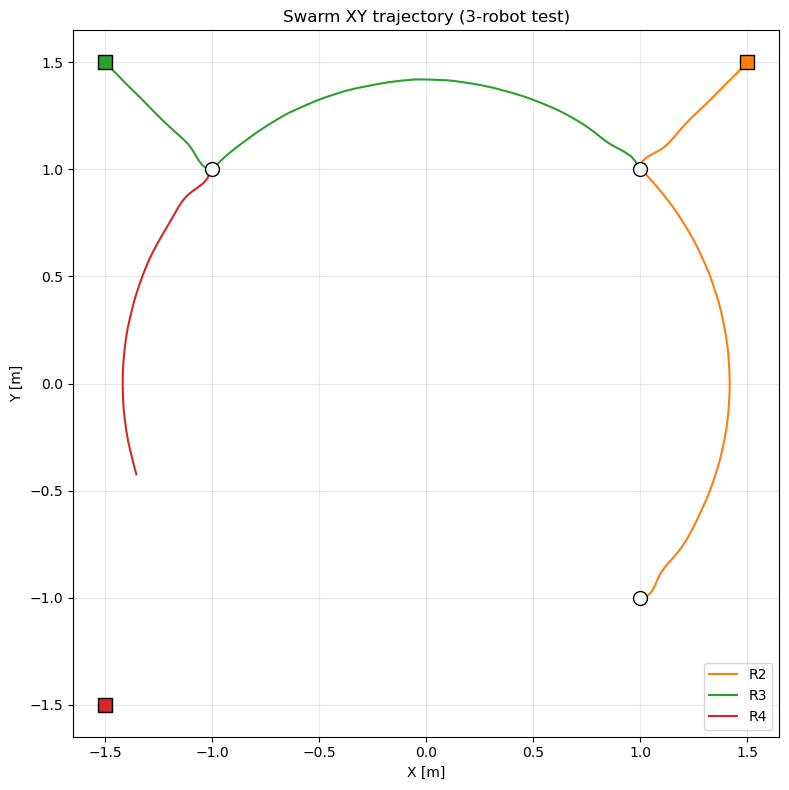

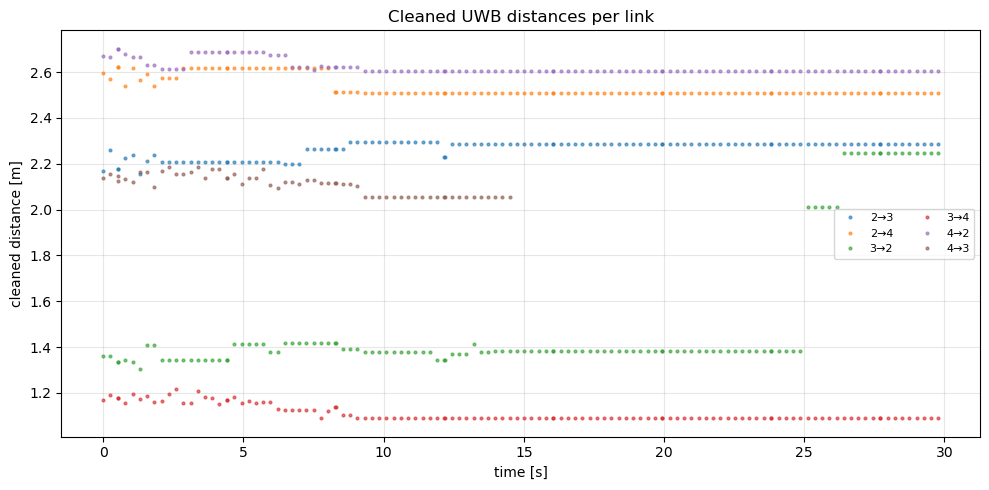

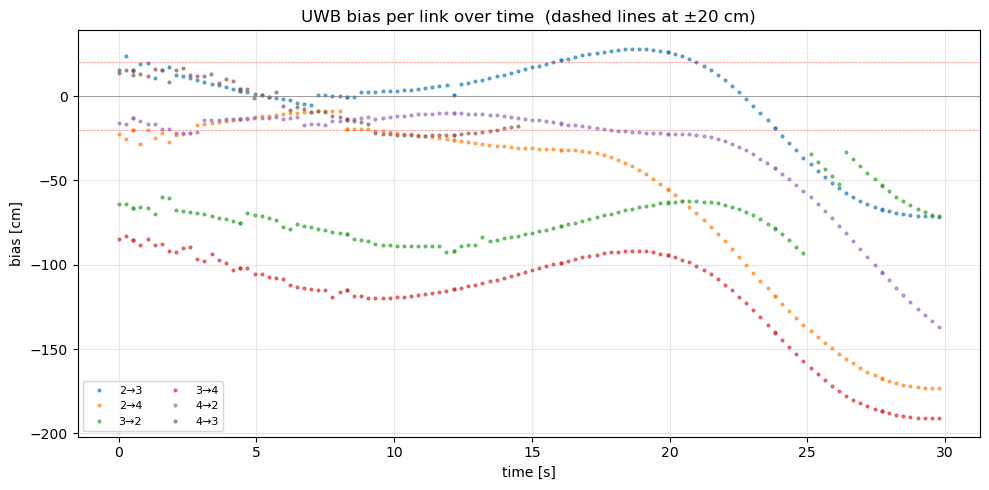

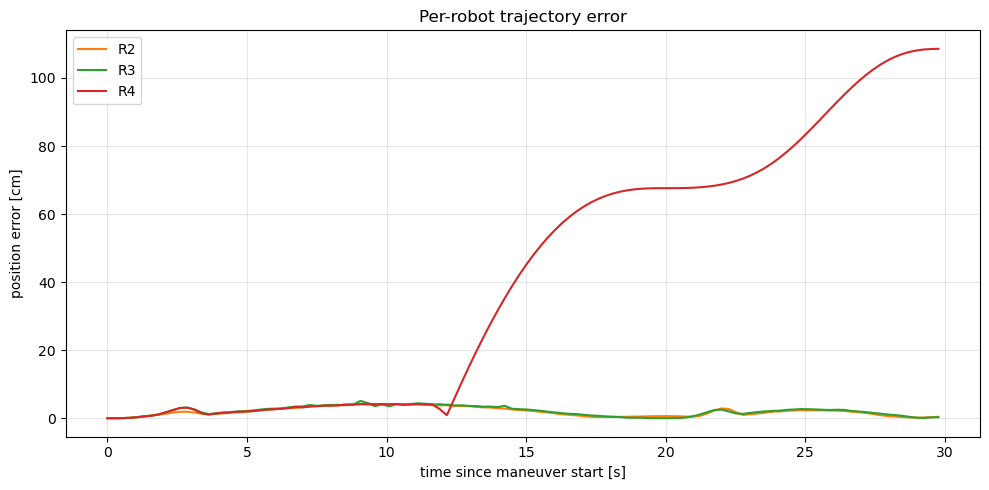

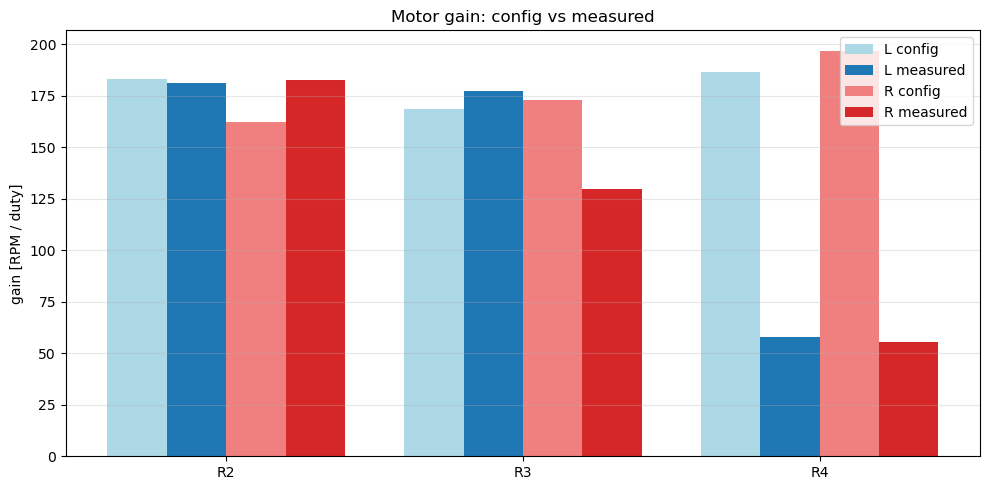

In [2]:
# ============================================================
# 3-robot test — cleaned analysis with separate plots
# ============================================================
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 300)

# ------------------------------------------------------------
# 0. Load
# ------------------------------------------------------------
FILES = {2: "robot_2_v2.csv", 3: "robot_3_v2.csv", 4: "robot_4_v2.csv"}

data_raw = {}
for rb, fname in FILES.items():
    p = Path(fname)
    if p.exists():
        data_raw[rb] = pd.read_csv(p)

# ------------------------------------------------------------
# 1. Outlier rejection
# ------------------------------------------------------------
# Valid range: 0 < dist < 200 m (physical envelope)
# Also reject any clean value outside [-5, +50] m
UWB_RAW_MIN   = 0.0
UWB_RAW_MAX   = 200.0
UWB_CLEAN_MIN = -5.0
UWB_CLEAN_MAX = 50.0

def is_valid_uwb(raw, clean):
    return (UWB_RAW_MIN < raw < UWB_RAW_MAX and
            UWB_CLEAN_MIN < clean < UWB_CLEAN_MAX)

print("=" * 100)
print(" [1] OUTLIER REJECTION SUMMARY")
print("=" * 100)
print(f"{'robot':>5s} | {'block':>6s} | {'total':>6s} | "
      f"{'valid':>6s} | {'rejected':>9s} | {'reason':>30s}")
print("-" * 84)

data = {}
for rb, d in data_raw.items():
    d = d.copy()
    data[rb] = d

    for i in (1, 2, 3):
        raw_col = f"uwb{i}_raw"
        cln_col = f"uwb{i}_clean"
        if raw_col not in d.columns: continue

        raw_arr = d[raw_col].values
        cln_arr = d[cln_col].values

        # Count bad raw
        bad_raw = int(np.sum(~((raw_arr > UWB_RAW_MIN) & (raw_arr < UWB_RAW_MAX))))
        bad_cln = int(np.sum(~((cln_arr > UWB_CLEAN_MIN) & (cln_arr < UWB_CLEAN_MAX))))

        # Nonzero samples
        nz = int(np.sum(np.abs(raw_arr) > 1e-6))
        valid = int(np.sum(
            (np.abs(raw_arr) > 1e-6) &
            (raw_arr > UWB_RAW_MIN) & (raw_arr < UWB_RAW_MAX) &
            (cln_arr > UWB_CLEAN_MIN) & (cln_arr < UWB_CLEAN_MAX)
        ))
        rejected = nz - valid
        reason = f"bad_raw={bad_raw}, bad_cln={bad_cln}"

        print(f"{rb:>5d} | uwb{i:>6d} | {len(d):>6d} | "
              f"{valid:>6d} | {rejected:>9d} | {reason:>30s}")

# ============================================================
# 2. Build link_data with only valid samples
# ============================================================
link_data = {}
for rb, d in data.items():
    for i in (1, 2, 3):
        peer_col = f"uwb{i}_peer_id"
        raw_col  = f"uwb{i}_raw"
        cln_col  = f"uwb{i}_clean"
        rssi_col = f"uwb{i}_rssi"
        fp_col   = f"uwb{i}_fp_power"
        noise_col = f"uwb{i}_std_noise"
        if peer_col not in d.columns: continue

        for _, row in d.iterrows():
            peer = int(row[peer_col])
            raw  = row[raw_col]
            cln  = row[cln_col]
            if not is_valid_uwb(raw, cln): continue
            key = (rb, peer)
            link_data.setdefault(key, []).append({
                "t_ms": int(row["t_ms"]),
                "raw":   raw,
                "clean": cln,
                "rssi":  row[rssi_col],
                "fp_power": row[fp_col],
                "noise": row[noise_col],
            })

# ============================================================
# 3. Timeline and TDMA (recap, on raw data)
# ============================================================
print("\n" + "=" * 100)
print(" [2] TIMELINE AND TDMA STATE")
print("=" * 100)
print(f"{'robot':>5s} | {'t_first':>9s} | {'t_last':>9s} | {'dur[s]':>7s} | "
      f"{'n':>4s} | {'frame_min':>10s} {'frame_max':>10s} | "
      f"{'sync_lost':>10s}")
print("-" * 94)
for rb, d in data.items():
    print(f"{rb:>5d} | {int(d['t_ms'].iloc[0]):>9d} | "
          f"{int(d['t_ms'].iloc[-1]):>9d} | "
          f"{(d['t_ms'].iloc[-1]-d['t_ms'].iloc[0])/1000.0:>7.2f} | "
          f"{len(d):>4d} | "
          f"{int(d['tdma_frame_id'].min()):>10d} "
          f"{int(d['tdma_frame_id'].max()):>10d} | "
          f"{d['tdma_sync_lost'].mean():>10.3f}")

# ============================================================
# 4. LINK-LEVEL UWB AFTER CLEANING
# ============================================================
print("\n" + "=" * 100)
print(" [3] LINK-LEVEL UWB AFTER CLEANING")
print("=" * 100)
print(f"{'link':>6s} | {'n':>4s} | "
      f"{'raw_mean':>10s} | {'clean_mean':>11s} | "
      f"{'clean_std':>10s} | {'rssi_mean':>10s} | {'noise_mean':>11s}")
print("-" * 84)
for key in sorted(link_data.keys()):
    vals = link_data[key]
    if len(vals) < 3: continue
    raw_m   = np.mean([v["raw"]      for v in vals])
    clean_m = np.mean([v["clean"]    for v in vals])
    clean_s = np.std([v["clean"]     for v in vals])
    rssi_m  = np.mean([v["rssi"]     for v in vals])
    noise_m = np.mean([v["noise"]    for v in vals])
    print(f"{key[0]}->{key[1]} | {len(vals):>4d} | "
          f"{raw_m:>+10.3f} | {clean_m:>+11.3f} | "
          f"{clean_s:>10.3f} | {rssi_m:>+10.2f} | {noise_m:>11.1f}")

# ============================================================
# 5. MOTOR HEALTH CHECK
# ============================================================
print("\n" + "=" * 100)
print(" [4] MOTOR HEALTH CHECK")
print("=" * 100)
print("  Compare measured gain to configured value.")
print("  A healthy motor should be within ±20% of config.\n")

CONFIG_GAIN = {
    (2, "L"): 182.89, (2, "R"): 162.03,
    (3, "L"): 168.66, (3, "R"): 172.92,
    (4, "L"): 186.47, (4, "R"): 196.83,
}

print(f"{'robot':>5s} | {'side':>3s} | {'meas':>8s} | "
      f"{'config':>8s} | {'ratio':>7s} | {'verdict':>10s}")
print("-" * 58)
for rb, d in data.items():
    if "robot_state" not in d.columns: continue
    dr = d[d["robot_state"] == 1]
    if len(dr) < 20: continue
    for side, duty_col, rpm_col in [("L", "duty_l", "rpm_l"),
                                     ("R", "duty_r", "rpm_r")]:
        duty = dr[duty_col].values
        rpm  = dr[rpm_col].values
        mf = (duty > 0.05) & (rpm > 5.0)
        if mf.sum() > 10:
            db = float(duty[mf].min())
            A = np.vstack([duty[mf] - db, np.ones(mf.sum())]).T
            coef, *_ = np.linalg.lstsq(A, rpm[mf], rcond=None)
            gain = float(coef[0])
        else:
            gain = np.nan
        cfg = CONFIG_GAIN.get((rb, side), np.nan)
        ratio = gain / cfg if (not np.isnan(gain) and cfg > 0) else np.nan
        if np.isnan(ratio):
            verdict = "?"
        elif 0.8 < ratio < 1.2:
            verdict = "OK"
        elif 0.5 < ratio < 0.8:
            verdict = "DEGRADED"
        else:
            verdict = "FAILED"
        print(f"{rb:>5d} | {side:>3s} | {gain:>8.2f} | "
              f"{cfg:>8.2f} | {ratio:>7.3f} | {verdict:>10s}")

# ============================================================
# 6. BIAS vs GT (clean data)
# ============================================================
L_INITIAL     = 2.0
L_FINAL       = 3.0
ROT_FINAL_RAD = np.pi / 2
T1_ROT_SEC    = 20.0
T2_SCALE_SEC  = 10.0
T_TOTAL_SEC   = T1_ROT_SEC + T2_SCALE_SEC
UNIT_OFFSET = {2: (+0.5, -0.5), 3: (+0.5, +0.5), 4: (-0.5, +0.5)}

def quintic(s): return 10*s**3 - 15*s**4 + 6*s**5

def ref_pose(rb, t_elapsed):
    if t_elapsed < T1_ROT_SEC:
        tau = t_elapsed / T1_ROT_SEC
        s = quintic(max(0.0, min(1.0, tau)))
        phi = ROT_FINAL_RAD * s; L = L_INITIAL
    elif t_elapsed < T_TOTAL_SEC:
        tau = (t_elapsed - T1_ROT_SEC) / T2_SCALE_SEC
        s = quintic(max(0.0, min(1.0, tau)))
        phi = ROT_FINAL_RAD
        L = L_INITIAL + (L_FINAL - L_INITIAL) * s
    else:
        phi = ROT_FINAL_RAD; L = L_FINAL
    rx, ry = UNIT_OFFSET[rb]
    c, s_ = np.cos(phi), np.sin(phi)
    return c * L * rx - s_ * L * ry, s_ * L * rx + c * L * ry, phi

maneuver_start = {}
for rb, d in data.items():
    if "robot_state" not in d.columns: continue
    first_run = np.where(d["robot_state"].values == 1)[0]
    maneuver_start[rb] = int(d["t_ms"].iloc[first_run[0]]) if len(first_run) else -1

print("\n" + "=" * 100)
print(" [5] BIAS vs GROUND-TRUTH  (clean data only)")
print("=" * 100)
print(f"{'link':>6s} | {'n':>4s} | "
      f"{'gt_mean':>9s} | {'clean_mean':>11s} | "
      f"{'bias [cm]':>10s} | {'rmse [cm]':>10s} | "
      f"{'drift [cm]':>11s}")
print("-" * 82)

bias_records = {}  # store for plotting

for key in sorted(link_data.keys()):
    rb_i, rb_j = key
    if rb_i not in maneuver_start or rb_j not in maneuver_start: continue
    t0_i = maneuver_start[rb_i]; t0_j = maneuver_start[rb_j]
    if t0_i < 0 or t0_j < 0: continue
    vals = link_data[key]
    if len(vals) < 10: continue

    t_arr = np.array([v["t_ms"] for v in vals])
    cln_arr = np.array([v["clean"] for v in vals])
    gt_arr = []
    for v in vals:
        xa, ya, _ = ref_pose(rb_i, (v["t_ms"] - t0_i) / 1000.0)
        xb, yb, _ = ref_pose(rb_j, (v["t_ms"] - t0_j) / 1000.0)
        gt_arr.append(np.hypot(xa - xb, ya - yb))
    gt_arr = np.array(gt_arr)
    bias = (cln_arr - gt_arr) * 100

    # Drift = std of bias over time (only if >10 samples)
    drift = float(np.std(bias))

    bias_records[key] = {
        "t_ms": t_arr, "clean": cln_arr, "gt": gt_arr, "bias": bias
    }

    print(f"{rb_i}->{rb_j} | {len(vals):>4d} | "
          f"{gt_arr.mean():>9.3f} | {cln_arr.mean():>11.3f} | "
          f"{bias.mean():>+10.2f} | {np.sqrt(np.mean(bias**2)):>10.2f} | "
          f"{drift:>11.2f}")

# ============================================================
# 7. PLOT 1 — Swarm trajectory
# ============================================================
colors = {2: "tab:orange", 3: "tab:green", 4: "tab:red"}

fig, ax = plt.subplots(figsize=(8, 8))
for rb, d in data.items():
    ax.plot(d["x"], d["y"], color=colors[rb], lw=1.5, label=f"R{rb}")
for rb in (2, 3, 4):
    rx, ry = UNIT_OFFSET[rb]
    xi, yi = L_INITIAL * rx, L_INITIAL * ry
    c, s = np.cos(ROT_FINAL_RAD), np.sin(ROT_FINAL_RAD)
    xf = c * L_FINAL * rx - s * L_FINAL * ry
    yf = s * L_FINAL * rx + c * L_FINAL * ry
    ax.plot(xi, yi, "o", color=colors[rb], ms=10,
            markeredgecolor="black", markerfacecolor="white")
    ax.plot(xf, yf, "s", color=colors[rb], ms=10, markeredgecolor="black")
ax.set_aspect("equal")
ax.set_xlabel("X [m]"); ax.set_ylabel("Y [m]")
ax.set_title("Swarm XY trajectory (3-robot test)")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("plot1_trajectory.png", dpi=120)
plt.show()

# ============================================================
# 8. PLOT 2 — Cleaned UWB distances over time
# ============================================================
fig, ax = plt.subplots(figsize=(10, 5))
for key in sorted(bias_records.keys()):
    rec = bias_records[key]
    t_arr = rec["t_ms"] / 1000.0
    t_rel = t_arr - t_arr[0]
    ax.plot(t_rel, rec["clean"], ".", ms=4, alpha=0.6,
            label=f"{key[0]}→{key[1]}")
ax.set_xlabel("time [s]")
ax.set_ylabel("cleaned distance [m]")
ax.set_title("Cleaned UWB distances per link")
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("plot2_cleaned_distances.png", dpi=120)
plt.show()

# ============================================================
# 9. PLOT 3 — Bias per link over time
# ============================================================
fig, ax = plt.subplots(figsize=(10, 5))
for key in sorted(bias_records.keys()):
    rec = bias_records[key]
    t_arr = rec["t_ms"] / 1000.0
    t_rel = t_arr - t_arr[0]
    ax.plot(t_rel, rec["bias"], ".", ms=4, alpha=0.6,
            label=f"{key[0]}→{key[1]}")
ax.axhline(0, color="gray", lw=0.5)
ax.axhline(+20, color="red", ls="--", lw=0.5, alpha=0.5)
ax.axhline(-20, color="red", ls="--", lw=0.5, alpha=0.5)
ax.set_xlabel("time [s]")
ax.set_ylabel("bias [cm]")
ax.set_title("UWB bias per link over time  (dashed lines at ±20 cm)")
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("plot3_bias_per_link.png", dpi=120)
plt.show()

# ============================================================
# 10. PLOT 4 — Per-robot trajectory error over time
# ============================================================
fig, ax = plt.subplots(figsize=(10, 5))
for rb, d in data.items():
    if "robot_state" not in d.columns: continue
    dr = d[d["robot_state"] == 1]
    if len(dr) < 10: continue
    t0_own = dr["t_ms"].iloc[0]
    errs = []
    t_rel = []
    for _, row in dr.iterrows():
        te = (row["t_ms"] - t0_own) / 1000.0
        if te < 0 or te > T_TOTAL_SEC + 3: continue
        xr, yr, _ = ref_pose(rb, te)
        errs.append(np.hypot(row["x"] - xr, row["y"] - yr) * 100)
        t_rel.append(te)
    ax.plot(t_rel, errs, color=colors[rb], lw=1.5, label=f"R{rb}")
ax.set_xlabel("time since maneuver start [s]")
ax.set_ylabel("position error [cm]")
ax.set_title("Per-robot trajectory error")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("plot4_trajectory_error.png", dpi=120)
plt.show()

# ============================================================
# 11. PLOT 5 — Motor gain per robot
# ============================================================
fig, ax = plt.subplots(figsize=(10, 5))

gain_data = {rb: {} for rb in data}
for rb, d in data.items():
    if "robot_state" not in d.columns: continue
    dr = d[d["robot_state"] == 1]
    if len(dr) < 20: continue
    for side, duty_col, rpm_col in [("L", "duty_l", "rpm_l"),
                                     ("R", "duty_r", "rpm_r")]:
        duty = dr[duty_col].values
        rpm  = dr[rpm_col].values
        mf = (duty > 0.05) & (rpm > 5.0)
        if mf.sum() > 10:
            db = float(duty[mf].min())
            A = np.vstack([duty[mf] - db, np.ones(mf.sum())]).T
            coef, *_ = np.linalg.lstsq(A, rpm[mf], rcond=None)
            gain_data[rb][side] = float(coef[0])
        else:
            gain_data[rb][side] = np.nan

rbs = sorted(gain_data.keys())
L_gains = [gain_data[rb].get("L", np.nan) for rb in rbs]
R_gains = [gain_data[rb].get("R", np.nan) for rb in rbs]
L_cfg = [CONFIG_GAIN.get((rb, "L"), np.nan) for rb in rbs]
R_cfg = [CONFIG_GAIN.get((rb, "R"), np.nan) for rb in rbs]

x = np.arange(len(rbs))
w = 0.2
ax.bar(x - 1.5*w, L_cfg,   width=w, label="L config",   color="lightblue")
ax.bar(x - 0.5*w, L_gains, width=w, label="L measured", color="tab:blue")
ax.bar(x + 0.5*w, R_cfg,   width=w, label="R config",   color="lightcoral")
ax.bar(x + 1.5*w, R_gains, width=w, label="R measured", color="tab:red")
ax.set_xticks(x)
ax.set_xticklabels([f"R{rb}" for rb in rbs])
ax.set_ylabel("gain [RPM / duty]")
ax.set_title("Motor gain: config vs measured")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("plot5_motor_gain.png", dpi=120)
plt.show()